In [1]:
'''
WORKFLOW
Cleaning
1. Import site data
2. Take years that have beengapfilled, remove NA
3. Plot to check

Analysis
4. Select threshold limits and generate values
5. Get noise and switching rates at each threshold
6. Run methane model on noise
7. Store and group by threshld to get pdf

Export
8. Plot and save
'''

'\nWORKFLOW\nCleaning\n1. Import site data\n2. Take years that have beengapfilled, remove NA\n3. Plot to check\n\nAnalysis\n4. Select threshold limits and generate values\n5. Get noise and switching rates at each threshold\n6. Run methane model on noise\n7. Store and group by threshld to get pdf\n\nExport\n8. Plot and save\n'

In [19]:
'''Imports'''
#General python packages
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import random

#Utils
from functions import *

def jitter(x, lim = 1):
    return [s + random.uniform(-lim, lim) for s in x]

In [20]:
'''Params'''
#Params
k_p = 2
k_ox = 1
k_om = 6
k_e = 0.2

k_max = 1
a_max = 1000

#Nondimensionalized
b = k_p/k_ox
g = k_p/k_om
e = k_e/k_max
a = 1/a_max

dt = 0.1

In [21]:

'''(1) Import Normalized Data'''
#site list: "CA-SCB", "DE-Hte", "DE-Zrk", "FI-Si2", "FI-Sii", "FR-LGt", "JP-BBY", "NZ-KOP", "SE-DEG"
sitename = "SE-DEG"
daily = pd.read_csv('data/cleaned/' + sitename + '_normalized.csv')

Text(0.5, 0.98, 'SE-DEG')

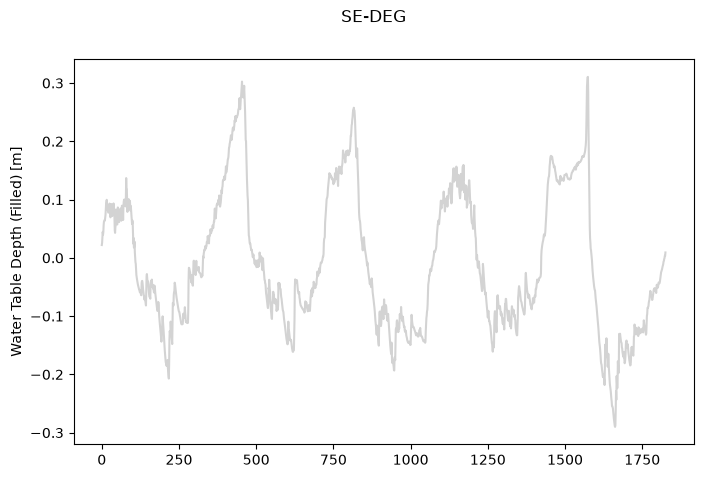

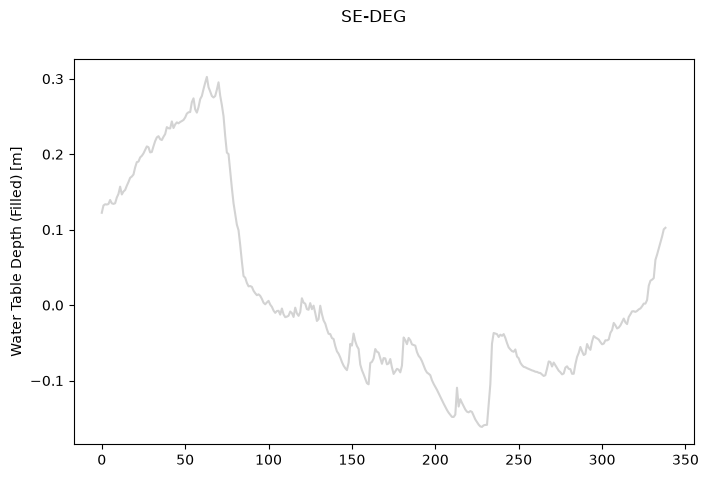

In [22]:
'''(2, 3) Select Data'''
fig, ax = plt.subplots(figsize = (8, 5))
plt.plot(daily.WTD_F, zorder = 5, color = 'lightgray')
ax.set(ylabel = 'Water Table Depth (Filled) [m]')
plt.suptitle(sitename)

#%%
#Select a bit of WTE data that contains no missing data. 
#   CA-SCB [516:1247]
#   DE-Hte [2188:2672]
#   DE-Zrk [1095:1576, 1660:2190]
#   FI-Si2 Do not use
#   FI-Sii Do not use
#   FR-LGt [238:407, 424:711]
#   JP-BBY [all]
#   NZ-NOP [all]
#   SE-SfN Do not use
#   SE-DEG [391:730]
WTD_sample = daily.WTD_F[391:730].dropna().reset_index(drop = True)
meth_sample = daily.FCH4_F_NORM[391:730].reset_index(drop = True)

fig, ax = plt.subplots(figsize = (8, 5))
plt.plot(WTD_sample, zorder = 5, color = 'lightgray')
#plt.plot(meth_sample, zorder = 5, color = 'black')
ax.set(ylabel = 'Water Table Depth (Filled) [m]')
plt.suptitle(sitename)

In [23]:
'''(4, 5) Pull switching rates from each of the chosen thresholds'''
nbin = 20
l_limit = -0.15 
u_limit = 0.3
#Redefine thresh to increase samples
#   CA-SCB np.linspace(-0.25, 0.05, 30)
#   JP-BBY np.linspace(-0.20, 0.15, 30)
#   NZ-KOP np.linspace(-0.25, -0.05, 30)
#   DE-Hte np.linspace(-0.6, -0.25, 30)
#   DE-Zrk np.linspace(-0.1, 0.4, 30)
#   FR-LGt np.linspace(-0.35, -0.15, 30)
#   SE-DEG np.linspace(-0.15, 0.3, 30)
thresh,depthStep = np.linspace(l_limit, u_limit, nbin, retstep = True)

#Rerun decomp
storage_N = pd.DataFrame(np.zeros((len(WTD_sample), len(thresh))))

#The probability of being in state 1 is k2/(k1+k2) and in state 2 is k1/(k1+k2)
k1_values = []
k2_values = []
crosses = []

for i in range(0, len(thresh)):
    #Threshold
    t = thresh[i]

    #Derive noise
    k1, k2, N = switch_param(WTD_sample, t)

    #Save derived noise
    storage_N[i] = N

    #Calculate crosses
    cross = ncrosses(WTD_sample.reset_index(drop=True), t)

    k1_values.append(k1)
    k2_values.append(k2)
    crosses.append(cross)

#Combine into a dataframe
derivedK = pd.DataFrame([thresh, k1_values, k2_values, crosses]).transpose()
derivedK.columns = ['thresholds', 'k1', 'k2', 'crosses']

In [24]:
derivedK

,thresholds,k1,k2,crosses
0,-0.150000,0.003021,0.125000,2.0
1,-0.126316,0.003195,0.038462,6.0
2,-0.102632,0.003311,0.027027,4.0
3,-0.078947,0.003937,0.011765,14.0
4,-0.055263,0.004762,0.007752,10.0
5,-0.031579,0.005988,0.005814,2.0
6,-0.007895,0.007407,0.004902,12.0
7,0.015789,0.009615,0.004255,2.0
8,0.039474,0.010870,0.004049,2.0
9,0.063158,0.011111,0.004016,2.0


In [25]:
'''(6) Run coupled methane/acetate simulation'''
#Use the switching rates previously derived

#Empty df for values
storage_thresh = pd.DataFrame({'Time' : [], 
                               'Noise' : [], 
                               'Acetate': [], 
                               'Methane' : [], 
                               'Emission' : [], 
                               'Threshold' : []})

for i in range(0, len(thresh)):
    noise = pd.DataFrame({'x' : np.array(range(0, len(WTD_sample))),
                         'noise' : np.array(storage_N[i])})
    
    noise_resampled = downsample(noise, 'x', 0.1)

    #Run numerical solution
    s = rk4_solve_ma(0.5, 0.5, 0.1, noise_resampled,
                     kp = k_p, kox = k_ox, kom = k_om, e = e)
    
    s['Threshold'] = thresh[i]

    #Concat
    storage_thresh = pd.concat((storage_thresh, s))

c:\Users\mwjones\OneDrive - DOI\Desktop\Projects\PAUSED - Critical Wetland Inundation\dichotomous\functions.py:165: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  s.Acetate[0], s.Methane[0],  = a_init, m_init
c:\Users\mwjones\OneDrive - DOI\Desktop\Projects\PAUSED - Critical Wetland Inundation\dichotomous\functions.py:180: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the origina

In [26]:
'''TEST (7) Groupby day (time step) to get total daily emission from all threshold crossings'''
storage_thresh['Day'] = np.floor(storage_thresh.Time)
thresh_daily_pdf = storage_thresh.groupby('Day').sum().reset_index()
thresh_daily_pdf['Emission_converted'] = thresh_daily_pdf.Emission*1000*(depthStep)*(1/dt)
thresh_daily_pdf['Emission_converted_uncum'] = np.diff(thresh_daily_pdf.Emission_converted, prepend=thresh_daily_pdf.Emission_converted[0])
thresh_daily_pdf.drop(thresh_daily_pdf.tail(1).index, inplace = True)
thresh_daily_pdf

,Day,Time,Noise,Acetate,Methane,Emission,Threshold,Emission_converted,Emission_converted_uncum
0,0.0,90.0,40.0,0.0,0.0,0.0,15.0,0.0,0.0
1,1.0,290.0,40.0,0.0,0.0,0.0,15.0,0.0,0.0
2,2.0,490.0,40.0,0.0,0.0,0.0,15.0,0.0,0.0
3,3.0,690.0,40.0,0.0,0.0,0.0,15.0,0.0,0.0
4,4.0,890.0,48.0,0.0,0.0,0.0,15.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
333,333.0,66690.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0
334,334.0,66890.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0
335,335.0,67090.0,8.0,0.0,0.0,0.0,15.0,0.0,0.0
336,336.0,67290.0,20.0,0.0,0.0,0.0,15.0,0.0,0.0


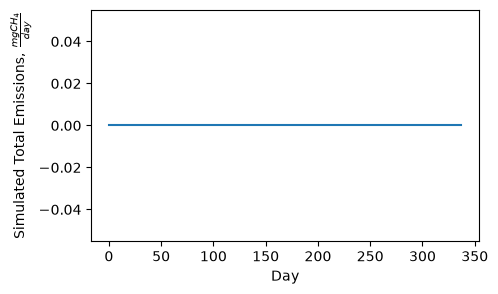

c:\Users\mwjones\OneDrive - DOI\Desktop\Projects\PAUSED - Critical Wetland Inundation\dichotomous\.venv2\Lib\site-packages\scipy\stats\_stats_py.py:10940: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm


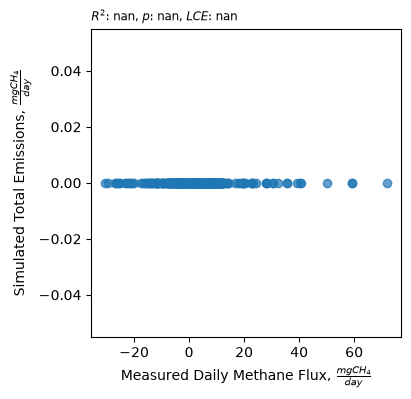

In [10]:

#%%
'''(8) Plot'''
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

ax.plot(thresh_daily_pdf.Day, thresh_daily_pdf.Emission_converted_uncum)

#ax.set_xlim(l_limit, u_limit)
ax.set_xlabel('Day')
ax.set_ylabel(r'Simulated Total Emissions, $\frac{mgCH_4}{day}$')

plt.savefig("figures/sites/" + sitename + "_emissions.pdf", bbox_inches = 'tight')
plt.show() 


fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(x = meth_sample[0:-1], y = thresh_daily_pdf.Emission_converted_uncum, 
        alpha = 0.7,
        marker = 'o')

r2, p = calc_corr(meth_sample[0:-1], thresh_daily_pdf.Emission_converted_uncum)
lce = calcLCE(meth_sample[0:-1], thresh_daily_pdf.Emission_converted_uncum)
plt.title(r'$R^2$: ' + str(round(r2, 2)) + r', $p$: ' + str(round(p, 5)) + r', $LCE$: ' + str(round(lce, 3)), size = 'small', loc = 'left')

#ax.set_xlim(-0.25, 0.05)
ax.set_xlabel(r'Measured Daily Methane Flux, $\frac{mgCH_4}{day}$')
ax.set_ylabel(r'Simulated Total Emissions, $\frac{mgCH_4}{day}$')

plt.savefig("figures/sites/" + sitename + "_model_data_comparison.pdf", bbox_inches = 'tight')
plt.show() 


In [18]:
'''(9) Run optimization on dichotomous model to fit to data'''
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition

def blackbox_dichotomous(k_p, k_ox, k_om, e):
    #Empty df for values
    storage_temp = pd.DataFrame({'Time' : [], 
                                'Noise' : [], 
                                'Acetate': [], 
                                'Methane' : [], 
                                'Emission' : [], 
                                'Threshold' : []})

    #generate noise
    for i in range(0, len(thresh)):
        noise = pd.DataFrame({'x' : np.array(range(0, len(WTD_sample))),
                            'noise' : np.array(storage_N[i])})
        
        noise_resampled = downsample(noise, 'x', dt)

        #Run numerical solution
        s = rk4_solve_ma(0.5, 0.5, 0.1, noise_resampled,
                        kp = k_p, kox = k_ox, kom = k_om, e = e)
        
        s['Threshold'] = thresh[i]

        #Concat
        storage_temp = pd.concat((storage_temp, s))
        
    #column summation
    storage_temp['Day'] = np.floor(storage_temp.Time)
    storage_temp_column = storage_temp.groupby('Day').sum().reset_index()
    storage_temp_column['Emission_converted'] = storage_temp_column.Emission*1000*(depthStep)*(1/dt)
    storage_temp_column['Emission_converted_uncum'] = np.diff(storage_temp_column.Emission_converted, prepend=storage_temp_column.Emission_converted[0])
    storage_temp_column.drop(storage_temp_column.tail(1).index, inplace = True)
    
    #compute correlation
    lce = calcLCE(meth_sample[0:-1], storage_temp_column.Emission_converted_uncum)
    
    return lce
    

In [19]:
#Aquisition function
acquisition_function = acquisition.UpperConfidenceBound(kappa = 1)

optimizer = BayesianOptimization(f = blackbox_dichotomous, 
                                    acquisition_function = acquisition_function,
                                    pbounds = {'k_p': (0,10),
                                               'k_ox': (0, 10), 
                                               'k_om' : (0, 10), 
                                               'e' : (0, 10)}, 
                                    random_state = 75832, 
                                    verbose = 0
                                    )
#logger object records optimization search
#logger = JSONLogger(path="dichotomous_optimization_" + sitename + ".json", reset = False)
#optimizer.subscribe(Events.OPTIMIZATION_STEP, logger)


'''RUN OPTIMIZATION'''
optimizer.maximize(init_points = 10, n_iter = 10)

c:\Users\mwjones\OneDrive - DOI\Desktop\Projects\PAUSED - Critical Wetland Inundation\dichotomous\functions.py:161: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  s.Acetate[0], s.Methane[0],  = a_init, m_init
c:\Users\mwjones\OneDrive - DOI\Desktop\Projects\PAUSED - Critical Wetland Inundation\dichotomous\functions.py:176: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the origina

ValueError: Input y contains NaN.